In [1]:
import pandas as pd
from functools import reduce
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

import folium
from folium import plugins
import seaborn as sns
import numpy as np

In [2]:
spatial_data = gpd.read_file(r'E:\01_UCL\08_Dissertation\02_DataProcessing\01_SpaceSyntax_London\London.gpkg')
spatial_data.head()  # Prints the first 5 rows of the loaded data to see what it looks like.

,ID,METRES,MER_ID,MER_GID,CODE,OSODR,NUMBER,ROAD_NAME,INDICATOR,CLASS,...,OA11CD,WZ11CD,LSOA11CD,LSOA11NM,MSOA11CD,MSOA11NM,LAD11CD,LAD11NM,SCALE,geometry
0,562736,73.389373,1088986,959901,3004,O167UFWW0X5TW,None,AMBERLEY ROAD,None,minor,...,E00006966,E33033554,E01001399,Enfield 021B,E02000297,Enfield 021,E09000010,Enfield,1,"MULTILINESTRING ((533496 194642, 533521 194711))"
1,562783,215.139490,1088799,123965,3001,O167UQGW0PQTW,A105,VILLAGE ROAD,None,aroad,...,E00007209,E33033558,E01001455,Enfield 021F,E02000297,Enfield 021,E09000010,Enfield,3,"MULTILINESTRING ((532979 195192, 532937 194981))"
2,562784,95.566731,1088800,123989,3001,O167V15W0VVAW,A105,RIDGE AVENUE,None,aroad,...,E00006964,E33033556,E01001402,Enfield 021D,E02000297,Enfield 021,E09000010,Enfield,3,"MULTILINESTRING ((532451 194748, 532358 194770))"
3,562785,135.712932,1088801,124028,3001,O167V2XD0VGAW,A105,RIDGE AVENUE,None,aroad,...,E00006964,E33033556,E01001402,Enfield 021D,E02000297,Enfield 021,E09000010,Enfield,3,"MULTILINESTRING ((532358 194770, 532225 194797))"
4,562786,109.110036,1088802,124062,3001,O167V6CD0XHTW,A105,GREEN LANES,None,aroad,...,E00007244,E33033562,E01001456,Enfield 022A,E02000298,Enfield 022,E09000010,Enfield,3,"MULTILINESTRING ((532019 194636, 532123 194669))"


# 1 Process .tsv Files


### Extract London safer scores with locations

In [3]:
# Step 1: Read the tsv files 
places_df = pd.read_csv(r'E:\01_UCL\08_Dissertation\01_DataCollection\01 Place Pluse2.0 Dataset\00 place-pulse-dataset-images _OriginalDatasdet\places.tsv', sep='\t')
location_df = pd.read_csv(r'E:\01_UCL\08_Dissertation\01_DataCollection\01 Place Pluse2.0 Dataset\00 place-pulse-dataset-images _OriginalDatasdet\locations.tsv', sep='\t')
qscores_df = pd.read_csv(r'E:\01_UCL\08_Dissertation\01_DataCollection\01 Place Pluse2.0 Dataset\00 place-pulse-dataset-images _OriginalDatasdet\qscores.tsv', sep='\t')

# Step 2: Find the place_id for London
london_place_id = places_df[places_df['place_name'] == 'London']['_id'].values[0]

# Step 3: Filter location and qscore data for London
london_location_df = location_df[location_df['place_id'] == london_place_id]
london_qscores_df = qscores_df[qscores_df['place_id'] == london_place_id]

# Step 4: Emerge the London qscores with the location data
merged_df = pd.merge(
    london_qscores_df,
    london_location_df,
    left_on='location_id',
    right_on='_id'
)

# Step 5: Select and rename the final columns
result_df = merged_df[['location_id', 'trueskill.score', 'loc.1', 'loc.0']]
result_df.columns = ['location_id', 'qscore', 'longitude', 'latitude']

# Step 6: Save the final result to a CSV file
result_df.to_csv(r'E:\01_UCL\08_Dissertation\02_DataProcessing\00_ExtractData_PP\london_qscore_with_location.csv', index=False)


print(result_df.head())

                location_id     qscore  longitude   latitude
0  513e1fe5fdc9f0358700a065  24.441260   0.028367  51.487970
1  513e1b0bfdc9f03587009376  21.240814  -0.183391  51.550568
2  513e20a7fdc9f0358700a26b  25.498906  -0.057636  51.493597
3  513e1e78fdc9f03587009c92  25.467112  -0.137536  51.600800
4  513e1a98fdc9f03587009259  28.492709   0.059908  51.573847


### Merge "Safer" Perception Scores with London Image Locations

In [4]:
# Step 1: Read the Safer Trueskill data
safer_df = pd.read_csv(r'E:\01_UCL\08_Dissertation\02_DataProcessing\00_ExtractData_PP\PP_Safer_Trueskill.csv')

# Step 2: Read London qscore + Loacstion data
london_df = pd.read_csv(r'E:\01_UCL\08_Dissertation\02_DataProcessing\00_ExtractData_PP\london_qscore_with_location.csv')

# Step 3: Filter Safer data for the 'safer' study question
safer_filtered = safer_df[safer_df['study_question'] == 'safer']

# Step 4: Connect the Safer data with the London location data
merged_df = pd.merge(london_df, safer_filtered, on='location_id', how='inner')

# Step 5: Select the final columns
final_df = merged_df[['location_id', 'longitude', 'latitude', 'trueskill.score', 'trueskill_norm']]

final_df = final_df.drop_duplicates(subset=['location_id'])

# Step 6:  Save the final result to a CSV file
final_df.to_csv(r'E:\01_UCL\08_Dissertation\02_DataProcessing\00_ExtractData_PP\london_safer_location.csv', index=False)


print(final_df.head())


                location_id  longitude   latitude  trueskill.score  \
0  513e1fe5fdc9f0358700a065   0.028367  51.487970        25.626842   
1  513e209ffdc9f0358700a259   0.061335  51.500405        22.052736   
2  513e1b52fdc9f03587009442   0.018176  51.509511        24.997293   
3  513e2103fdc9f0358700a364  -0.039795  51.564465        24.553454   
4  513e1abefdc9f035870092b8  -0.015149  51.536210        22.477479   

   trueskill_norm  
0        5.351312  
1        4.355878  
2        5.175975  
3        5.052360  
4        4.474174  


### Analyzing Perceptual Dimension Coverage of London Images

In [5]:
# Step 1: Read the London qscore + Location data
london_df = pd.read_csv(r'E:\01_UCL\08_Dissertation\02_DataProcessing\00_ExtractData_PP\london_qscore_with_location.csv')
london_df = london_df[['location_id', 'latitude', 'longitude']]  # 保留主键 + 坐标

# Step 2: Read the dimensions data
dimensions = {
    'safer': r'E:\01_UCL\08_Dissertation\01_DataCollection\01 Place Pluse2.0 Dataset\00 place-pulse-dataset-images _OriginalDatasdet\01代码运行产生的文件\02对比次数大于等于12的safer维度数据.csv',
    'wealthier': r'E:\01_UCL\08_Dissertation\01_DataCollection\01 Place Pluse2.0 Dataset\00 place-pulse-dataset-images _OriginalDatasdet\01代码运行产生的文件\02对比次数大于等于12的wealthier维度数据.csv',
    'livelier': r'E:\01_UCL\08_Dissertation\01_DataCollection\01 Place Pluse2.0 Dataset\00 place-pulse-dataset-images _OriginalDatasdet\01代码运行产生的文件\02对比次数大于等于12的livelier维度数据.csv',
    'more_depressing': r'E:\01_UCL\08_Dissertation\01_DataCollection\01 Place Pluse2.0 Dataset\00 place-pulse-dataset-images _OriginalDatasdet\01代码运行产生的文件\02对比次数大于等于12的more depressing维度数据.csv',
    'more_beautiful': r'E:\01_UCL\08_Dissertation\01_DataCollection\01 Place Pluse2.0 Dataset\00 place-pulse-dataset-images _OriginalDatasdet\01代码运行产生的文件\02对比次数大于等于12的more beautiful维度数据.csv',
    'more_boring': r'E:\01_UCL\08_Dissertation\01_DataCollection\01 Place Pluse2.0 Dataset\00 place-pulse-dataset-images _OriginalDatasdet\01代码运行产生的文件\02对比次数大于等于12的more boring维度数据.csv',
}

# Step 3: Construct flags for each dimension
dim_flags = []
for dim_name, path in dimensions.items():
    df = pd.read_csv(path)
    df = df[['location_id']].drop_duplicates()
    df[dim_name] = 1
    dim_flags.append(df)

# Step 4: Emerge all dimension flags on 'location_id'
merged_flags = reduce(lambda left, right: pd.merge(left, right, on='location_id', how='outer'), dim_flags)
merged_flags = merged_flags.fillna(0)

# Step 5: Combine with the London DataFrame
final_df = pd.merge(london_df, merged_flags, on='location_id', how='left')
final_df = final_df.fillna(0)  # 未参与的维度设为 0

# Step 6: Calculate the number of dimensions each location participates in
final_df['num_dimensions'] = final_df[list(dimensions.keys())].sum(axis=1)

# Step 7: Save the final DataFrame to a CSV file
final_df.to_csv(r'E:\01_UCL\08_Dissertation\02_DataProcessing\00_ExtractData_PP\london_dimension_participation.csv', index=False)

# Check the final DataFrame
print(final_df['num_dimensions'].value_counts().sort_index())


num_dimensions
0.0    9426
1.0    6186
2.0     480
Name: count, dtype: int64


# 2 Mapping images with safer data on London SpaceSyntax data 
### Combine the spatial_data with the result_df. 
### The spatial_data dataframe is lines, and result_df is points, so you need to match them by finding the closest line from spatial_data from every point in result_df 

## Pseudo-code: Orienting Images with Safety Scores on London Map

```
ALGORITHM: Orient Place Pulse Images with Safety Scores on London Street Network

INPUT:
- places.tsv: Place database with location identifiers
- locations.tsv: Geographic coordinates for each location  
- qscores.tsv: Quality scores and perception ratings
- safer_trueskill.csv: Normalized safety perception scores
- london_street_network.gpkg: Space Syntax street segments with INT2K and CH2K values

OUTPUT:
- Spatially oriented dataset linking images to street network with safety scores

PROCEDURE:
1. INITIALIZE empty datasets: londonSafetyData, spatialJoinResult

2. EXTRACT London locations:
   londonPlaceID ← FIND place_id WHERE place_name = 'London' IN places.tsv
   londonLocations ← FILTER locations.tsv WHERE place_id = londonPlaceID
   londonQScores ← FILTER qscores.tsv WHERE place_id = londonPlaceID

3. MERGE perception data:
   mergedData ← JOIN londonQScores WITH londonLocations ON location_id
   SELECT location_id, longitude, latitude, trueskill_score FROM mergedData

4. FILTER safety dimension:
   saferData ← FILTER safer_trueskill.csv WHERE study_question = 'safer'
   londonSafetyData ← JOIN mergedData WITH saferData ON location_id
   REMOVE duplicates based on location_id

5. CONVERT to spatial format:
   FOR each row IN londonSafetyData:
       geometry ← CREATE_POINT(longitude, latitude)
       SET coordinate_system TO WGS84 (EPSG:4326)

6. COORDINATE transformation:
   streetNetwork ← LOAD london_street_network.gpkg
   IF streetNetwork.CRS ≠ WGS84:
       streetNetwork ← TRANSFORM_CRS(streetNetwork, target=WGS84)
   
7. SPATIAL joining process:
   spatialJoinResult ← EMPTY dataset
   FOR each safetyPoint IN londonSafetyData:
       nearestStreet ← FIND_NEAREST_SEGMENT(safetyPoint, streetNetwork)
       distance ← CALCULATE_DISTANCE(safetyPoint, nearestStreet)
       
       IF distance < 50m:  // Proximity threshold
           ADD safetyPoint.location_id TO validPoints
           EXTRACT nearestStreet.INT2K, nearestStreet.CH2K
           
       spatialJoinResult ← APPEND {
           location_id: safetyPoint.location_id,
           coordinates: [latitude, longitude],
           safety_score: safetyPoint.trueskill_norm,
           integration: nearestStreet.INT2K,
           choice: nearestStreet.CH2K,
           distance_to_street: distance
       }

8. GENERATE final dataset:
   finalDataset ← SELECT location_id, lat, lon, safer_Trueskill_Scores, INT2K, CH2K 
                  FROM spatialJoinResult
   SAVE finalDataset TO 'London_RegressionModel_wgs84.csv'

9. VALIDATION:
   totalPoints ← COUNT(finalDataset)
   validMappings ← COUNT(finalDataset WHERE distance_to_street < 50m)
   mappingAccuracy ← (validMappings / totalPoints) × 100
   
   RETURN finalDataset, mappingAccuracy

END ALGORITHM

COMPLEXITY: O(n × m) where n = number of safety points, m = number of street segments
ASSUMPTIONS: 
- Street view images represent perception at nearest street segment
- 50m proximity threshold ensures reasonable spatial association
- WGS84 coordinate system provides sufficient accuracy for urban scale analysis
```

In [6]:
# Step 1: Read the spatial data (EPSG:27700)
spatial_data = gpd.read_file(r'E:\01_UCL\08_Dissertation\02_DataProcessing\01_SpaceSyntax_London\London.gpkg')
print("Spatial data CRS:", spatial_data.crs)  # Check if CRS is EPSG:27700 or not

# Step 2: Read the Place Pulse point data (WGS84)
result_df = pd.read_csv(r'E:\01_UCL\08_Dissertation\02_DataProcessing\00_ExtractData_PP\london_safer_location.csv')

# Step 3: Transform the Place Pulse point data into a GeoDataFrame and set the initial CRS to WGS84 (EPSG:4326)
# [ Note: the order of latitude and longitude is (longitude, latitude), because Place Pulse data is usually in longitude first, latitude second ]

geometry = [Point(xy) for xy in zip(result_df['longitude'], result_df['latitude'])]
result_gdf = gpd.GeoDataFrame(result_df, geometry=geometry, crs="EPSG:4326")

# Step 4: Transform the CRS of the Place Pulse points to match the spatial data (EPSG:27700)
result_gdf = result_gdf.to_crs(epsg=27700)

# Step 5: Spatial join to find the nearest line for each Place Pulse point
nearest_join = gpd.sjoin_nearest(result_gdf, spatial_data, how='left')

# Step 6: Save the results to a GeoPackage file
nearest_join.to_file(r'E:\01_UCL\08_Dissertation\02_DataProcessing\01_SpaceSyntax_London\london_point_line_nearest.gpkg', driver='GPKG')

# Check the first few rows of the nearest join result
print(nearest_join.head())

Spatial data CRS: EPSG:27700
                location_id  longitude   latitude  trueskill.score  \
0  513e1fe5fdc9f0358700a065   0.028367  51.487970        25.626842   
1  513e209ffdc9f0358700a259   0.061335  51.500405        22.052736   
2  513e1b52fdc9f03587009442   0.018176  51.509511        24.997293   
3  513e2103fdc9f0358700a364  -0.039795  51.564465        24.553454   
4  513e1abefdc9f035870092b8  -0.015149  51.536210        22.477479   

   trueskill_norm                       geometry  index_right       ID  \
0        5.351312  POINT (540923.965 178508.142)        33600  1801563   
1        4.355878  POINT (543173.698 179954.857)        69547   196145   
2        5.175975   POINT (540150.335 180883.94)       106791   403832   
3        5.052360  POINT (535963.952 186885.542)       101680   342282   
4        4.474174  POINT (537757.319 183789.585)        99845   341448   

       METRES  MER_ID  ...       INT100K     OA11CD     WZ11CD   LSOA11CD  \
0  211.516387  592903  ...  

### Generate Data for statistical model

In [7]:
print(spatial_data.columns)

Index(['ID', 'METRES', 'MER_ID', 'MER_GID', 'CODE', 'OSODR', 'NUMBER',
       'ROAD_NAME', 'INDICATOR', 'CLASS', 'CH2K', 'CH2KRANK', 'CH2KLOG',
       'NC2K', 'INT2K', 'INT2KRANK', 'CH10K', 'CH10KRANK', 'CH10KLOG', 'NC10K',
       'INT10K', 'INT10KRANK', 'CH100K', 'CH100KLOG', 'NC100K', 'INT100K',
       'OA11CD', 'WZ11CD', 'LSOA11CD', 'LSOA11NM', 'MSOA11CD', 'MSOA11NM',
       'LAD11CD', 'LAD11NM', 'SCALE', 'geometry'],
      dtype='object')


#### Using the WGS84 to calculate the distance

In [8]:
# Step 1: Read the spatial line data and ensure it's in WGS84 (EPSG:4326)
spatial_data = gpd.read_file(r'E:\01_UCL\08_Dissertation\02_DataProcessing\01_SpaceSyntax_London\london.gpkg')
spatial_data = spatial_data.to_crs(epsg=4326)  # Ensure WGS84
print("Spatial data CRS:", spatial_data.crs)

# Step 2: Read the Place Pulse point data
result_df = pd.read_csv(r'E:\01_UCL\08_Dissertation\02_DataProcessing\00_ExtractData_PP\london_safer_location.csv')
result_df.columns = result_df.columns.str.strip()  # Remove column name spaces

# Step 3: Convert to GeoDataFrame with WGS84 
geometry = [Point(xy) for xy in zip(result_df['longitude'], result_df['latitude'])]
result_gdf = gpd.GeoDataFrame(result_df, geometry=geometry, crs="EPSG:4326")

# Step 4: Spatial join to find the nearest line
nearest_join = gpd.sjoin_nearest(result_gdf, spatial_data, how='left')
nearest_join = nearest_join.drop_duplicates(subset=['location_id'])  # Remove duplicates based on location_id

# Step 5: Save as GeoPackage
nearest_join.to_file(
    r'E:\01_UCL\08_Dissertation\02_DataProcessing\01_SpaceSyntax_London\london_point_line_nearest_wgs84.gpkg',
    driver='GPKG'
)

# Step 6: Export CSV for regression analysis
final_df = nearest_join[['location_id', 'longitude', 'latitude', 'trueskill_norm', 'INT2K', 'CH2K']].copy()
final_df = final_df.rename(columns={
    'latitude': 'lat',
    'longitude': 'lon',
    'trueskill_norm': 'safer_Trueskill_Scores'
})
final_df.to_csv(
    r'E:\01_UCL\08_Dissertation\02_DataProcessing\01_SpaceSyntax_London\London_RegressionModel_wgs84.csv',
    index=False
)

# Step 7: Check the first few rows
print(final_df.head())
print(nearest_join.shape)

Spatial data CRS: EPSG:4326


d:\APPs\anaconda\settings\envs\Dissertation_Env\Lib\site-packages\geopandas\array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


                location_id       lon        lat  safer_Trueskill_Scores  \
0  513e1fe5fdc9f0358700a065  0.028367  51.487970                5.351312   
1  513e209ffdc9f0358700a259  0.061335  51.500405                4.355878   
2  513e1b52fdc9f03587009442  0.018176  51.509511                5.175975   
3  513e2103fdc9f0358700a364 -0.039795  51.564465                5.052360   
4  513e1abefdc9f035870092b8 -0.015149  51.536210                4.474174   

        INT2K          CH2K  
0  138.804631    692.500000  
1   48.435399   2451.000000  
2  177.682814  16115.166992  
3  171.911070   5793.000000  
4   98.571771      0.000000  
(900, 42)


Basic data information:
Number of data points: 900
Column names: ['location_id', 'lon', 'lat', 'safer_Trueskill_Scores', 'INT2K', 'CH2K']

Data statistics:
              lon         lat  safer_Trueskill_Scores       INT2K  \
count  900.000000  900.000000              900.000000  900.000000   
mean    -0.102409   51.525633                5.773213  191.189768   
std      0.095044    0.045434                1.267981   91.429278   
min     -0.309881   51.438005                0.807531   15.215654   
25%     -0.171548   51.488474                4.956526  130.224478   
50%     -0.100651   51.525153                5.858810  178.311988   
75%     -0.028534   51.561816                6.638535  236.731857   
max      0.075764   51.618121                9.637296  677.206962   

                CH2K  
count     900.000000  
mean    11932.681811  
std     19902.157588  
min         0.000000  
25%       947.000000  
50%      3904.416626  
75%     15338.687500  
max    201083.171875  

Interactive ma

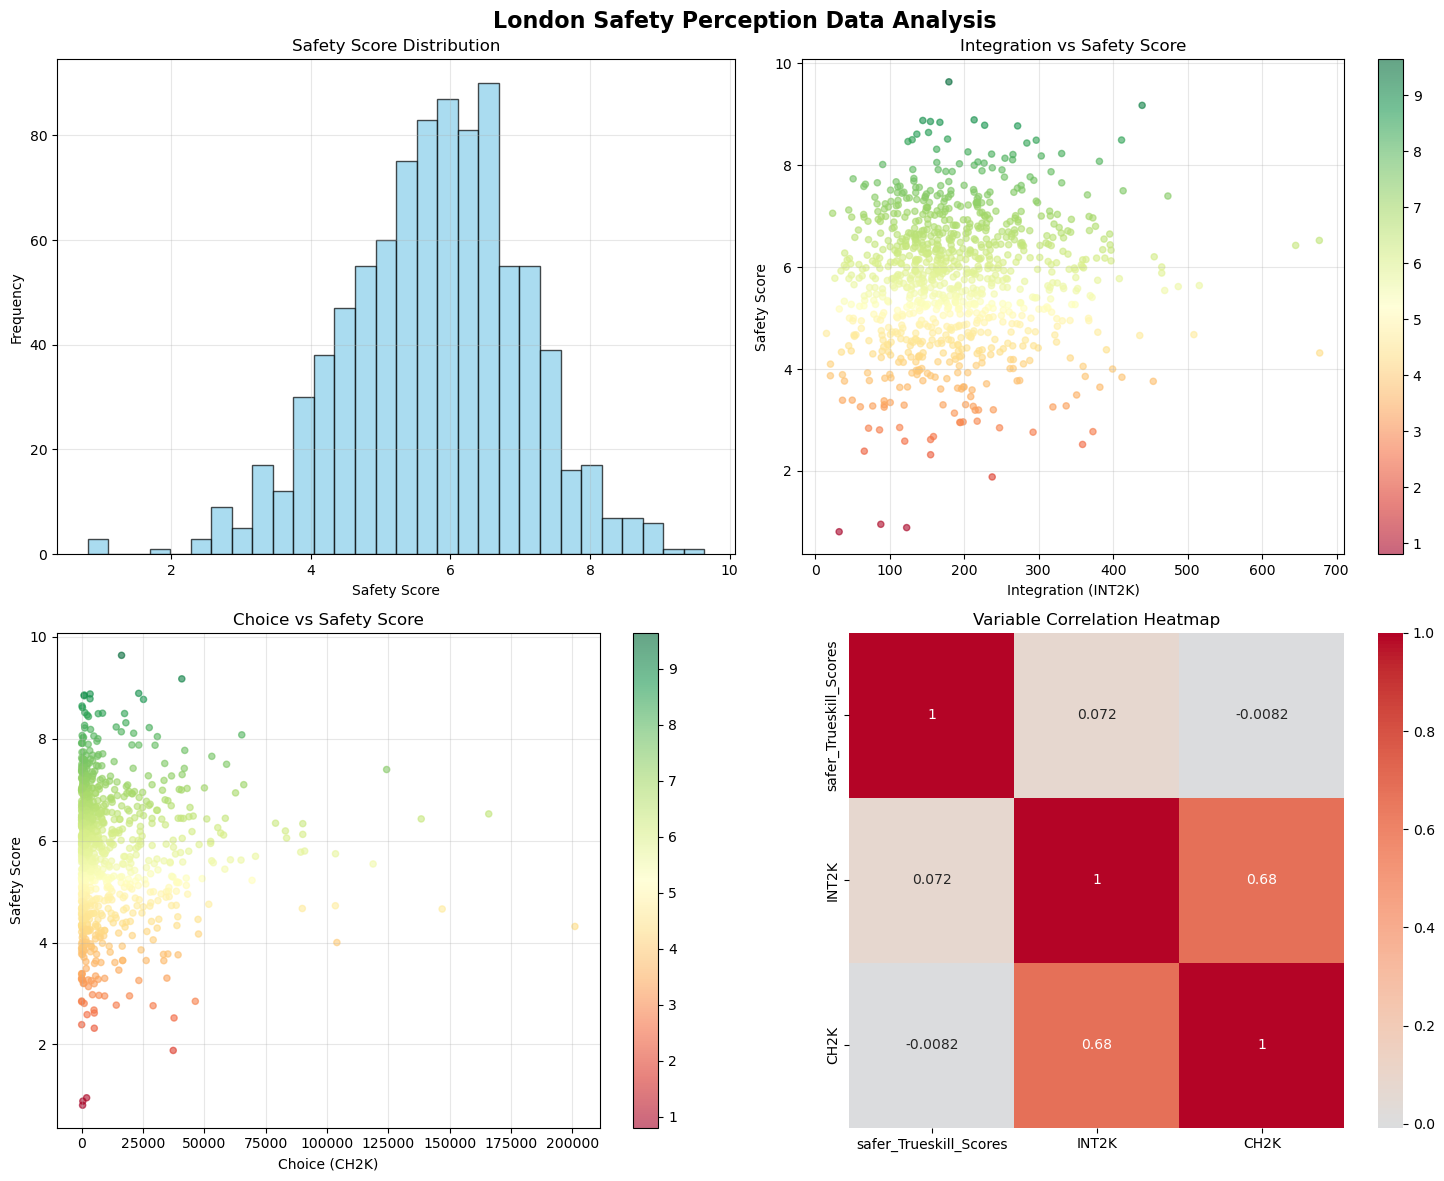


=== Data Analysis Results ===
Safety score range: 0.808 - 9.637
Safety score mean: 5.773
Safety score standard deviation: 1.268

Integration range: 15.216 - 677.207
Choice range: 0.000 - 201083.172

Correlation between safety score and integration: 0.072
Correlation between safety score and choice: -0.008


In [9]:
# Read CSV data
df = pd.read_csv(r'E:\01_UCL\08_Dissertation\02_DataProcessing\01_SpaceSyntax_London\London_RegressionModel_wgs84.csv')

print("Basic data information:")
print(f"Number of data points: {len(df)}")
print(f"Column names: {df.columns.tolist()}")
print("\nData statistics:")
print(df.describe())

# Create interactive map
def create_safety_map(data, map_center=None):
    """
    Create interactive map for safety perception data
    """
    if map_center is None:
        # Calculate data center point
        center_lat = data['lat'].mean()
        center_lon = data['lon'].mean()
        map_center = [center_lat, center_lon]
    
    # Create base map
    m = folium.Map(
        location=map_center,
        zoom_start=10,
        tiles='OpenStreetMap'
    )
    
    # Add different base map options
    folium.TileLayer('CartoDB positron').add_to(m)
    folium.TileLayer('CartoDB dark_matter').add_to(m)
    
    # Create color mapping based on safety scores
    def get_color(score):
        """Return color based on safety perception score"""
        if pd.isna(score):
            return 'gray'
        elif score <= 0.2:
            return 'red'
        elif score <= 0.4:
            return 'orange'
        elif score <= 0.6:
            return 'yellow'
        elif score <= 0.8:
            return 'lightgreen'
        else:
            return 'green'
    
    # Add data points
    for idx, row in data.iterrows():
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=5,
            popup=f"""
            <b>Location ID:</b> {row['location_id']}<br>
            <b>Safety Score:</b> {row['safer_Trueskill_Scores']:.3f}<br>
            <b>Integration (INT2K):</b> {row['INT2K']:.3f}<br>
            <b>Choice (CH2K):</b> {row['CH2K']:.3f}<br>
            <b>Coordinates:</b> ({row['lat']:.4f}, {row['lon']:.4f})
            """,
            tooltip=f"Safety Score: {row['safer_Trueskill_Scores']:.3f}",
            color='black',
            weight=1,
            fillColor=get_color(row['safer_Trueskill_Scores']),
            fillOpacity=0.7
        ).add_to(m)
    
    # Add heatmap layer
    heat_data = [[row['lat'], row['lon'], row['safer_Trueskill_Scores']] 
                 for idx, row in data.iterrows() if not pd.isna(row['safer_Trueskill_Scores'])]
    
    plugins.HeatMap(heat_data, name='Safety Perception Heatmap').add_to(m)
    
    # Add layer control
    folium.LayerControl().add_to(m)
    
    # Add legend
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; left: 50px; width: 150px; height: 120px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px">
    <b>Safety Score</b><br>
    <i class="fa fa-circle" style="color:red"></i> 0.0 - 0.2 (Very Unsafe)<br>
    <i class="fa fa-circle" style="color:orange"></i> 0.2 - 0.4 (Unsafe)<br>
    <i class="fa fa-circle" style="color:yellow"></i> 0.4 - 0.6 (Neutral)<br>
    <i class="fa fa-circle" style="color:lightgreen"></i> 0.6 - 0.8 (Safe)<br>
    <i class="fa fa-circle" style="color:green"></i> 0.8 - 1.0 (Very Safe)<br>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    return m

# Create map
safety_map = create_safety_map(df)

# Save map
output_path = r'E:\01_UCL\08_Dissertation\02_DataProcessing\01_SpaceSyntax_London\london_safety_map.html'
safety_map.save(output_path)
print(f"\nInteractive map saved to: {output_path}")

# Create static statistical charts
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('London Safety Perception Data Analysis', fontsize=16, fontweight='bold')

# 1. Safety score distribution histogram
axes[0, 0].hist(df['safer_Trueskill_Scores'].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Safety Score Distribution')
axes[0, 0].set_xlabel('Safety Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# 2. Integration vs Safety score scatter plot
scatter = axes[0, 1].scatter(df['INT2K'], df['safer_Trueskill_Scores'], 
                            alpha=0.6, c=df['safer_Trueskill_Scores'], 
                            cmap='RdYlGn', s=20)
axes[0, 1].set_title('Integration vs Safety Score')
axes[0, 1].set_xlabel('Integration (INT2K)')
axes[0, 1].set_ylabel('Safety Score')
axes[0, 1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0, 1])

# 3. Choice vs Safety score scatter plot
scatter2 = axes[1, 0].scatter(df['CH2K'], df['safer_Trueskill_Scores'], 
                             alpha=0.6, c=df['safer_Trueskill_Scores'], 
                             cmap='RdYlGn', s=20)
axes[1, 0].set_title('Choice vs Safety Score')
axes[1, 0].set_xlabel('Choice (CH2K)')
axes[1, 0].set_ylabel('Safety Score')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1, 0])

# 4. Correlation heatmap
correlation_data = df[['safer_Trueskill_Scores', 'INT2K', 'CH2K']].corr()
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', center=0, 
            square=True, ax=axes[1, 1])
axes[1, 1].set_title('Variable Correlation Heatmap')

plt.tight_layout()
plt.savefig(r'E:\01_UCL\08_Dissertation\02_DataProcessing\01_SpaceSyntax_London\london_safety_analysis.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# Print basic statistical information
print("\n=== Data Analysis Results ===")
print(f"Safety score range: {df['safer_Trueskill_Scores'].min():.3f} - {df['safer_Trueskill_Scores'].max():.3f}")
print(f"Safety score mean: {df['safer_Trueskill_Scores'].mean():.3f}")
print(f"Safety score standard deviation: {df['safer_Trueskill_Scores'].std():.3f}")

print(f"\nIntegration range: {df['INT2K'].min():.3f} - {df['INT2K'].max():.3f}")
print(f"Choice range: {df['CH2K'].min():.3f} - {df['CH2K'].max():.3f}")

# Calculate correlation coefficients
corr_int = df['safer_Trueskill_Scores'].corr(df['INT2K'])
corr_ch = df['safer_Trueskill_Scores'].corr(df['CH2K'])
print(f"\nCorrelation between safety score and integration: {corr_int:.3f}")
print(f"Correlation between safety score and choice: {corr_ch:.3f}")

In [10]:
# Read CSV data
df = pd.read_csv(r'E:\01_UCL\08_Dissertation\02_DataProcessing\01_SpaceSyntax_London\London_RegressionModel_wgs84.csv')

print("Basic data information:")
print(f"Number of data points: {len(df)}")
print(f"Column names: {df.columns.tolist()}")

# Check actual distribution of safety scores
print("\n=== Actual Safety Score Distribution Check ===")
print(f"Safety score statistics:")
print(f"  • Minimum: {df['safer_Trueskill_Scores'].min():.3f}")
print(f"  • Maximum: {df['safer_Trueskill_Scores'].max():.3f}")
print(f"  • Mean: {df['safer_Trueskill_Scores'].mean():.3f}")
print(f"  • Median: {df['safer_Trueskill_Scores'].median():.3f}")

def create_realistic_safety_map(data, map_center=None):
    """
    Create interactive safety perception map based on realistic classification standards
    Using reasonable safety rating thresholds: <1 dangerous, 1-5 unsafe, 5-6 neutral, 6-8 safe, >8 very safe
    """
    if map_center is None:
        center_lat = data['lat'].mean()
        center_lon = data['lon'].mean()
        map_center = [center_lat, center_lon]
    
    # Create base map
    m = folium.Map(
        location=map_center,
        zoom_start=11,
        tiles='OpenStreetMap'
    )
    
    # Add map title
    title_html = '''
                 <h3 align="center" style="font-size:20px; font-weight:bold; 
                 margin-top:0px; color:black; background-color:white; 
                 padding:10px; border:2px solid black; border-radius:5px;">
                 London Safety Perception Distribution Map<br>
                 <span style="font-size:14px; font-weight:normal;">
                 Safety Classification Visualization Based on Realistic Standards
                 </span>
                 </h3>
                 '''
    m.get_root().html.add_child(folium.Element(title_html))
    
    # Add different basemap options
    folium.TileLayer('CartoDB positron', name='Clean Map').add_to(m)
    folium.TileLayer('CartoDB dark_matter', name='Dark Map').add_to(m)
    folium.TileLayer('Stamen Terrain', name='Terrain Map').add_to(m)
    
    # Define adjusted safety classification thresholds
    thresholds = {
        'dangerous': 1.0,      # <1.0 dangerous
        'unsafe': 5.0,         # 1.0-5.0 unsafe  
        'neutral': 6.0,        # 5.0-6.0 neutral
        'safe': 8.0,           # 6.0-8.0 safe
        'very_safe': float('inf')  # >8.0 very safe
    }
    
    print(f"\n=== Adjusted Safety Classification Standards ===")
    print(f"Dangerous areas: < {thresholds['dangerous']:.1f}")
    print(f"Unsafe areas: {thresholds['dangerous']:.1f} - {thresholds['unsafe']:.1f}")
    print(f"Neutral areas: {thresholds['unsafe']:.1f} - {thresholds['neutral']:.1f}")
    print(f"Safe areas: {thresholds['neutral']:.1f} - {thresholds['safe']:.1f}")
    print(f"Very safe areas: > {thresholds['safe']:.1f}")
    
    # Color mapping based on realistic standards
    def get_color(score):
        """Return color based on realistic safety standards"""
        if pd.isna(score):
            return 'gray'
        elif score < thresholds['dangerous']:
            return 'darkred'      # dangerous - dark red
        elif score < thresholds['unsafe']:
            return 'red'          # unsafe - red
        elif score < thresholds['neutral']:
            return 'orange'       # neutral - orange
        elif score < thresholds['safe']:
            return 'lightgreen'   # safe - light green
        else:
            return 'darkgreen'    # very safe - dark green
    
    def get_safety_level(score):
        """Return safety level description"""
        if pd.isna(score):
            return "Unknown"
        elif score < thresholds['dangerous']:
            return "Dangerous"
        elif score < thresholds['unsafe']:
            return "Unsafe"
        elif score < thresholds['neutral']:
            return "Neutral"
        elif score < thresholds['safe']:
            return "Safe"
        else:
            return "Very Safe"
    
    def get_radius(score):
        """Return marker size based on score"""
        if pd.isna(score):
            return 4
        # Adjust size based on safety level
        if score < thresholds['dangerous']:
            return 6  # dangerous areas slightly larger
        elif score < thresholds['unsafe']:
            return 5
        elif score < thresholds['neutral']:
            return 4
        elif score < thresholds['safe']:
            return 5
        else:
            return 6  # very safe areas slightly larger
    
    # Coordinate formatting function
    def format_coordinates(lat, lon):
        lat_dir = 'N' if lat >= 0 else 'S'
        lat_abs = abs(lat)
        lon_dir = 'E' if lon >= 0 else 'W'  
        lon_abs = abs(lon)
        return f"{lat_abs:.4f}°{lat_dir}, {lon_abs:.4f}°{lon_dir}"
    
    # Create different marker groups
    safety_groups = {
        'Dangerous Areas (<1.0)': folium.FeatureGroup(name='Dangerous Areas (<1.0)'),
        'Unsafe Areas (1.0-5.0)': folium.FeatureGroup(name='Unsafe Areas (1.0-5.0)'),
        'Neutral Areas (5.0-6.0)': folium.FeatureGroup(name='Neutral Areas (5.0-6.0)'),
        'Safe Areas (6.0-8.0)': folium.FeatureGroup(name='Safe Areas (6.0-8.0)'),
        'Very Safe Areas (>8.0)': folium.FeatureGroup(name='Very Safe Areas (>8.0)')
    }
    
    # Count statistics for each classification
    classification_counts = {
        'Dangerous Areas (<1.0)': 0,
        'Unsafe Areas (1.0-5.0)': 0,
        'Neutral Areas (5.0-6.0)': 0,
        'Safe Areas (6.0-8.0)': 0,
        'Very Safe Areas (>8.0)': 0
    }
    
    # Add data points to corresponding groups
    for idx, row in data.iterrows():
        score = row['safer_Trueskill_Scores']
        
        if pd.isna(score):
            continue
            
        # Determine safety level group
        if score < thresholds['dangerous']:
            group_key = 'Dangerous Areas (<1.0)'
        elif score < thresholds['unsafe']:
            group_key = 'Unsafe Areas (1.0-5.0)'
        elif score < thresholds['neutral']:
            group_key = 'Neutral Areas (5.0-6.0)'
        elif score < thresholds['safe']:
            group_key = 'Safe Areas (6.0-8.0)'
        else:
            group_key = 'Very Safe Areas (>8.0)'
        
        classification_counts[group_key] += 1
        
        # Format coordinates
        formatted_coords = format_coordinates(row['lat'], row['lon'])
        safety_level = get_safety_level(score)
        
        # Create detailed popup information
        popup_html = f"""
        <div style="width:320px;">
            <h4 style="margin:0; color:darkblue;">Location Details</h4>
            <hr style="margin:5px 0;">
            <b>Location ID:</b> {row['location_id']}<br>
            <b>Safety Score:</b> <span style="color:{'darkgreen' if score >= 6.0 else ('orange' if score >= 5.0 else 'red')}; font-weight:bold;">
                {score:.3f}</span><br>
            <b>Safety Level:</b> <span style="color:{'darkgreen' if score >= 6.0 else ('orange' if score >= 5.0 else 'red')}; font-weight:bold;">
                {safety_level}</span><br>
            <b>Classification Group:</b> {group_key}<br>
            <hr style="margin:5px 0;">
            <b>Space Syntax Metrics:</b><br>
            • Integration (INT2K): {row['INT2K']:.3f}<br>
            • Choice (CH2K): {row['CH2K']:.3f}<br>
            <hr style="margin:5px 0;">
            <b>Geographic Coordinates:</b><br>
            <span style="color:darkblue; font-weight:bold;">{formatted_coords}</span><br>
            <small style="color:gray;">Latitude: {row['lat']:.4f} | Longitude: {row['lon']:.4f}</small>
        </div>
        """
        
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=get_radius(score),
            popup=folium.Popup(popup_html, max_width=340),
            tooltip=f"ID: {row['location_id']} | {safety_level}: {score:.3f} | {formatted_coords}",
            color='black',
            weight=1,
            fillColor=get_color(score),
            fillOpacity=0.8
        ).add_to(safety_groups[group_key])
    
    # Add all groups to map
    for group in safety_groups.values():
        group.add_to(m)
    
    # Add heatmap layer
    heat_data = [[row['lat'], row['lon'], row['safer_Trueskill_Scores']] 
                 for idx, row in data.iterrows() if not pd.isna(row['safer_Trueskill_Scores'])]
    
    heat_map = plugins.HeatMap(
        heat_data, 
        name='Safety Perception Heatmap',
        min_opacity=0.2,
        max_zoom=18,
        radius=15,
        blur=10,
        gradient={0.1: 'darkred', 0.3: 'red', 0.5: 'orange', 0.7: 'lightgreen', 1.0: 'darkgreen'}
    )
    heat_map.add_to(m)
    
    # Add clustered markers
    marker_cluster = plugins.MarkerCluster(name='Clustered Data Points').add_to(m)
    
    for idx, row in data.iterrows():
        if not pd.isna(row['safer_Trueskill_Scores']):
            formatted_coords = format_coordinates(row['lat'], row['lon'])
            safety_level = get_safety_level(row['safer_Trueskill_Scores'])
            
            folium.Marker(
                location=[row['lat'], row['lon']],
                popup=f"Safety Score: {row['safer_Trueskill_Scores']:.3f}<br>Safety Level: {safety_level}<br>Location: {formatted_coords}",
                icon=folium.Icon(
                    color='green' if row['safer_Trueskill_Scores'] >= 6.0 else ('orange' if row['safer_Trueskill_Scores'] >= 5.0 else 'red'),
                    icon='info-sign'
                )
            ).add_to(marker_cluster)
    
    # Add layer control
    folium.LayerControl(collapsed=False).add_to(m)
    
    # Add legend with adjusted standards
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; left: 50px; width: 300px; height: 240px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:12px; padding: 12px; border-radius:5px;
                box-shadow: 0 0 10px rgba(0,0,0,0.5);">
    <h4 style="margin:0 0 10px 0; color:darkblue;">Safety Score Legend (Adjusted Standards)</h4>
    <div style="margin:8px 0; line-height:1.5;">
        <i class="fa fa-circle" style="color:darkred"></i> <b>Dangerous Areas:</b> < 1.0<br>
        <i class="fa fa-circle" style="color:red"></i> <b>Unsafe Areas:</b> 1.0 - 5.0<br>
        <i class="fa fa-circle" style="color:orange"></i> <b>Neutral Areas:</b> 5.0 - 6.0<br>
        <i class="fa fa-circle" style="color:lightgreen"></i> <b>Safe Areas:</b> 6.0 - 8.0<br>
        <i class="fa fa-circle" style="color:darkgreen"></i> <b>Very Safe Areas:</b> > 8.0<br>
    </div>
    <hr style="margin:10px 0;">
    <small><b>Classification Notes:</b><br>
    Strict safety perception standards<br>
    Above 6 points = safe areas<br>
    Below 5 points = unsafe areas<br><br>
    <b>Coordinate Format:</b> Latitude°N/S, Longitude°E/W</small>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    # Add minimap
    minimap = plugins.MiniMap(toggle_display=True)
    m.add_child(minimap)
    
    # Add measurement tool
    plugins.MeasureControl().add_to(m)
    
    # Add fullscreen button
    plugins.Fullscreen().add_to(m)
    
    # Print classification statistics
    print(f"\n=== Realistic Standards Safety Level Distribution ===")
    total_points = sum(classification_counts.values())
    for level, count in classification_counts.items():
        percentage = (count / total_points) * 100 if total_points > 0 else 0
        print(f"  • {level}: {count} points ({percentage:.1f}%)")
    
    return m

# Create map based on realistic standards
print("Generating map based on realistic safety standards...")
realistic_map = create_realistic_safety_map(df)

# Save map
output_path = r'E:\01_UCL\08_Dissertation\02_DataProcessing\01_SpaceSyntax_London\realistic_london_safety_map.html'
realistic_map.save(output_path)
print(f"Interactive map with realistic standards saved to: {output_path}")

# Additional analysis: detailed score range distribution
print(f"\n=== Detailed Score Distribution Analysis ===")
scores = df['safer_Trueskill_Scores'].dropna()

# Adjusted range statistics
ranges = [
    (0, 1, "Dangerous Areas"),
    (1, 5, "Unsafe Areas"), 
    (5, 6, "Neutral Areas"),
    (6, 8, "Safe Areas"),
    (8, float('inf'), "Very Safe Areas")
]

for min_val, max_val, label in ranges:
    if max_val == float('inf'):
        count = len(scores[scores >= min_val])
        range_scores = scores[scores >= min_val]
    else:
        count = len(scores[(scores >= min_val) & (scores < max_val)])
        range_scores = scores[(scores >= min_val) & (scores < max_val)]
    
    percentage = (count / len(scores)) * 100
    if len(range_scores) > 0:
        avg_score = range_scores.mean()
        print(f"{label}: {count} points ({percentage:.1f}%), average score: {avg_score:.3f}")
    else:
        print(f"{label}: {count} points ({percentage:.1f}%)")

print(f"\n=== Final Data Statistics Summary ===")
print(f"Total data points: {len(df)}")
print(f"Safety score statistics:")
print(f"  • Minimum: {df['safer_Trueskill_Scores'].min():.3f}")
print(f"  • Maximum: {df['safer_Trueskill_Scores'].max():.3f}")
print(f"  • Mean: {df['safer_Trueskill_Scores'].mean():.3f}")
print(f"  • Median: {df['safer_Trueskill_Scores'].median():.3f}")
print(f"  • Standard deviation: {df['safer_Trueskill_Scores'].std():.3f}")

# Overall safe vs unsafe proportion (adjusted standards)
safe_count = len(scores[scores >= 6.0])
unsafe_count = len(scores[scores < 5.0])
neutral_count = len(scores[(scores >= 5.0) & (scores < 6.0)])

print(f"\n=== Overall Safety Status (Adjusted Standards) ===")
print(f"Safe areas (≥6.0 points): {safe_count} points ({(safe_count/len(scores)*100):.1f}%)")
print(f"Neutral areas (5.0-6.0 points): {neutral_count} points ({(neutral_count/len(scores)*100):.1f}%)")
print(f"Unsafe areas (<5.0 points): {unsafe_count} points ({(unsafe_count/len(scores)*100):.1f}%)")

Basic data information:
Number of data points: 900
Column names: ['location_id', 'lon', 'lat', 'safer_Trueskill_Scores', 'INT2K', 'CH2K']

=== Actual Safety Score Distribution Check ===
Safety score statistics:
  • Minimum: 0.808
  • Maximum: 9.637
  • Mean: 5.773
  • Median: 5.859
Generating map based on realistic safety standards...

=== Adjusted Safety Classification Standards ===
Dangerous areas: < 1.0
Unsafe areas: 1.0 - 5.0
Neutral areas: 5.0 - 6.0
Safe areas: 6.0 - 8.0
Very safe areas: > 8.0

=== Realistic Standards Safety Level Distribution ===
  • Dangerous Areas (<1.0): 3 points (0.3%)
  • Unsafe Areas (1.0-5.0): 232 points (25.8%)
  • Neutral Areas (5.0-6.0): 258 points (28.7%)
  • Safe Areas (6.0-8.0): 376 points (41.8%)
  • Very Safe Areas (>8.0): 31 points (3.4%)
Interactive map with realistic standards saved to: E:\01_UCL\08_Dissertation\02_DataProcessing\01_SpaceSyntax_London\realistic_london_safety_map.html

=== Detailed Score Distribution Analysis ===
Dangerous Areas: